# Tanzania Water Wells 
### A Classification Model for the Tanzanian Ministry of Water

**Author:** Angela Masaki

**Date:** 29/04/2026 - 05/05/2026

**Dataset:** DrivenData — Pump It Up: Data Mining the Water Table

DrivenData. (2015). Pump it Up: Data Mining the Water Table. Retrieved [April 29 2026] from https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table.

-----

## 1. Business Understanding

### 1.1 Problem Statement

Tanzania is an East African country of over 60 million people, many of whom depend on water wells (waterpoints) for daily survival. A significant portion of these wells are non-functional or in need of repair — leaving communities without access to clean, potable water.

Manually inspecting every well across a vast country is expensive and slow. A predictive model that identifies which wells are likely to be non-functional or in need of repair would allow authorities to **prioritize maintenance resources efficiently**, saving costs and improving water access at scale.

### 1.2 Stakeholders

| Stakeholder | Role | How They Use the Model |
|---|---|---|
| Tanzanian Ministry of Water | Primary | Allocate repair crews and budgets based on model predictions |
| NGOs (UNICEF) | Secondary | Identify which funded wells need follow-up maintenance |


### 1.3 How the Model Will Be Used

Given a set of well attributes (location, pump type, funder, construction year, etc.), the model will predict one of three classes:
- `functional` — well is working, no action needed
- `functional needs repair` — well is working but at risk; schedule maintenance
- `non functional` — well is broken; prioritize for urgent repair or replacement

This enables the Ministry to shift from **reactive** to **proactive** maintenance, reducing downtime and the number of communities left without water.

### 1.4 Success Metric

We will optimize for **recall on non-functional wells** — because the cost of missing a broken well (leaving a community without water) is far greater than the cost of a false alarm (sending a technician to inspect a functioning well).

----

# 2. Data Understanding 

## 2.1 Imports 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline

## 2.2 Data Source 
The dataset is sourced from **Taarifa** and the **Tanzanian Ministry of Water**, hosted on [DrivenData](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/) as part of the *Pump It Up* competition.

Three files are provided:
- `training_set_values.csv` — 59,400 rows × 40 feature columns
- `training_set_labels.csv` — 59,400 rows × 1 target column (`status_group`)
- `test_set_values.csv` — competition test set (no labels); not used in this project

**Why this data is suitable:** The features capture physical attributes (pump type, water quantity, construction year), geographic information (GPS, region), and management details (funder, installer) — all of which are plausibly linked to whether a well is functional.

In [46]:
# Load data — update paths to match your local directory
X_raw = pd.read_csv('../Data/training_set_values.csv', index_col='id')
y_raw = pd.read_csv('../Data/training_set_labels.csv', index_col='id')

# Merge for EDA
df = X_raw.join(y_raw)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (59400, 40)


,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


## 2.3 Dataset Size & Feature Type

In [47]:
print(f'Total rows:    {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]:,}  (including target)')
print()
print('Data types:')
print(df.dtypes.value_counts())
print()
print('Column list:')
print(df.columns.tolist())

Total rows:    59,400
Total columns: 40  (including target)

Data types:
object     31
int64       6
float64     3
Name: count, dtype: int64

Column list:
['amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [48]:
# Numerical Descriptive Statistics
df.describe()

,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [49]:
# Categorical Descriptive Statistics
df.describe(include='object')

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,recorded_by,scheme_management,scheme_name,permit,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,59400,55763,55745,59398,59400,59029,59400,59400,59400,56066,59400,55522,30590,56344,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400
unique,356,1896,2145,37399,9,19287,21,125,2092,2,1,11,2695,2,18,13,7,12,5,7,7,8,6,5,5,10,7,3,7,6,3
top,2011-03-15,Government Of Tanzania,DWE,none,Lake Victoria,Madukani,Iringa,Njombe,Igosi,True,GeoData Consultants Ltd,VWC,K,True,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,572,9084,17402,3563,10248,508,5294,2503,307,51011,59400,36793,682,38852,26780,26780,26780,40507,52490,25348,25348,50818,50818,33186,33186,17021,17021,45794,28522,34625,32259


## 2.4 Target Variable Distribution

Class Counts:
status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

Class Percentages:
status_group
functional                 54.31
non functional             38.42
functional needs repair     7.27
Name: proportion, dtype: float64


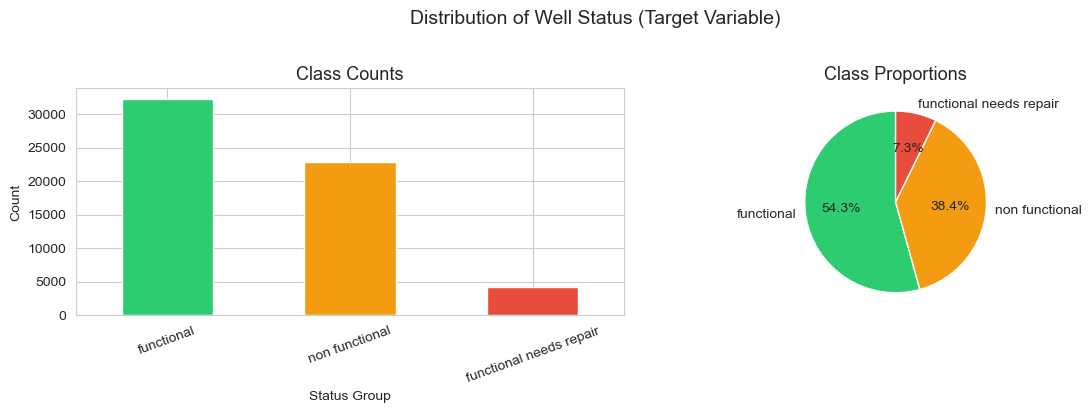

In [50]:
class_counts = df['status_group'].value_counts()
class_pct = df['status_group'].value_counts(normalize=True) * 100

print('Class Counts:')
print(class_counts)
print()
print('Class Percentages:')
print(class_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0],
                  color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0].set_title('Class Counts', fontsize=13)
axes[0].set_xlabel('Status Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                  colors=['#2ecc71', '#f39c12', '#e74c3c'],
                  startangle=90, legend=False)
axes[1].set_title('Class Proportions', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Distribution of Well Status (Target Variable)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Observation 

The dataset is imbalanced. Functional need repair makes up only 7% of the records and will hardest to predict and should be monitored carefully during modeling.

## 2.5 Missing Values

In [53]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({'missing_count': missing})


print('Columns with Missing Values:')
print(missing_df)

# Also check construction_year == 0 (invalid, treated as missing)
print(f"\nconstruction_year == 0 (treated as missing): {(df['construction_year'] == 0).sum():,}")
print(f"amount_tsh == 0 (check if meaningful): {(df['amount_tsh'] == 0).sum():,}")

Columns with Missing Values:
                       missing_count
amount_tsh                         0
date_recorded                      0
funder                          3637
gps_height                         0
installer                       3655
longitude                          0
latitude                           0
wpt_name                           2
num_private                        0
basin                              0
subvillage                       371
region                             0
region_code                        0
district_code                      0
lga                                0
ward                               0
population                         0
public_meeting                  3334
recorded_by                        0
scheme_management               3878
scheme_name                    28810
permit                          3056
construction_year                  0
extraction_type                    0
extraction_type_group              0
extractio

### Understanding

This identifies missing values but the handling of missing values is done inside the `preprocess()` function in **Section 4.3**

-----

# 3. Exploratory Data Analysis

## 3.1 Construction year 

In [57]:
# Colors used in visualizations
colors = {'functional': '#2ecc71', 'functional needs repair': '#f39c12', 'non functional': '#e74c3c'}

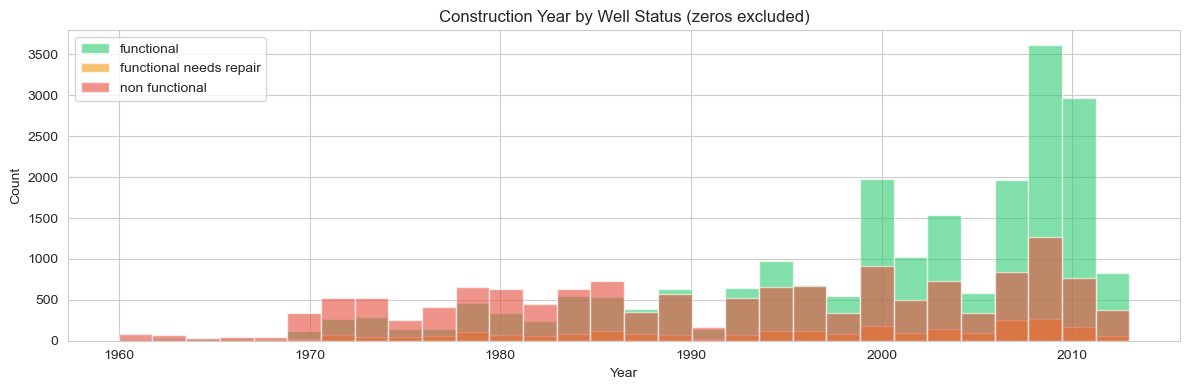

In [58]:
# Wells with year == 0 treated as missing
valid = df[df['construction_year'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 4))
for status, color in colors.items():
    ax.hist(valid[valid['status_group'] == status]['construction_year'],
            bins=30, alpha=0.6, label=status, color=color)
ax.set_title('Construction Year by Well Status (zeros excluded)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 3.2 Geographic Distribution

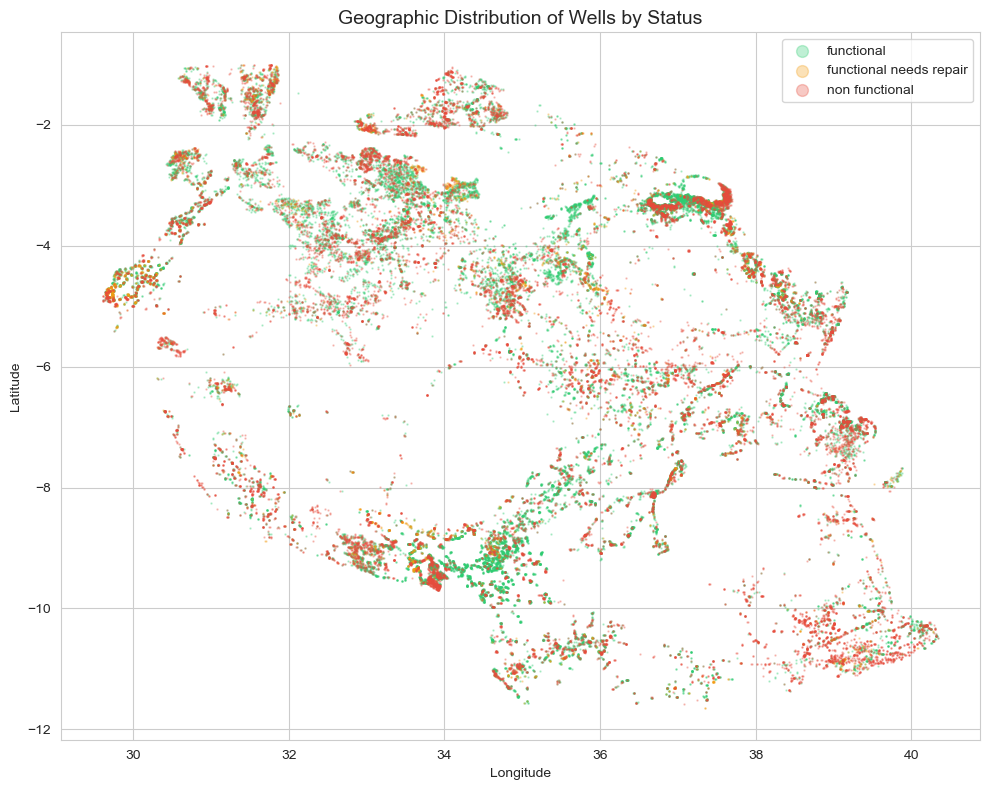

In [59]:
# Filter out clearly invalid GPS coordinates (0,0)
geo = df[(df['longitude'] > 1) & (df['latitude'] < -1)]

fig, ax = plt.subplots(figsize=(10, 8))
for status, color in colors.items():
    subset = geo[geo['status_group'] == status]
    ax.scatter(subset['longitude'], subset['latitude'],
               s=0.5, alpha=0.3, color=color, label=status)
ax.set_title('Geographic Distribution of Wells by Status', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=12, fontsize=10)
plt.tight_layout()
plt.show()

## 3.3 Non-Functional Rate 

Unique funders:    1896
Unique installers: 2145



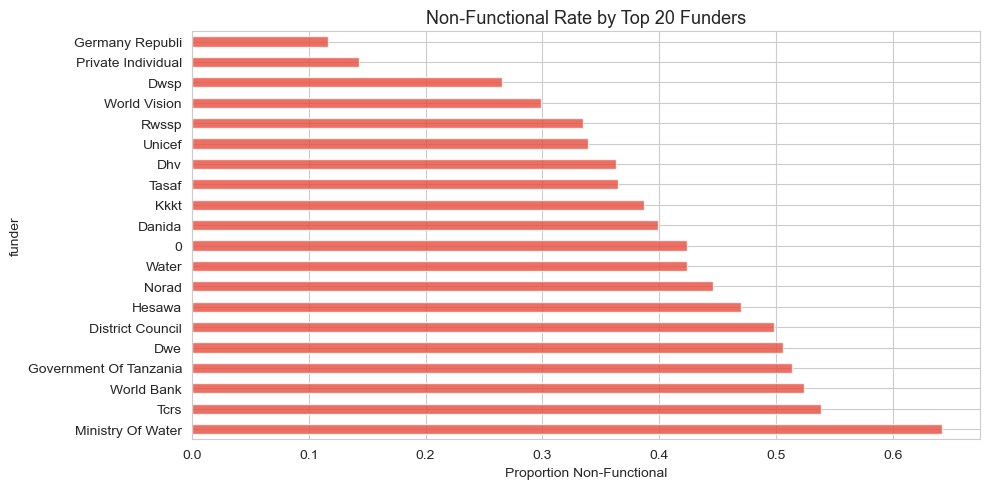

In [60]:
print(f"Unique funders:    {df['funder'].nunique()}")
print(f"Unique installers: {df['installer'].nunique()}")
print()

# Top 15 funders by non-functional rate
top_funders = df['funder'].value_counts().head(20).index
funder_nonfunc = (
    df[df['funder'].isin(top_funders)]
    .groupby('funder')['status_group']
    .apply(lambda x: (x == 'non functional').mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
funder_nonfunc.plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_title('Non-Functional Rate by Top 20 Funders', fontsize=13)
ax.set_xlabel('Proportion Non-Functional')
plt.tight_layout()
plt.show()

---

# 4. Data Preparation 

## 4.1 Feature Selection & Justification

In [61]:
# Columns to drop — documented rationale for each
cols_to_drop = [
    'wpt_name',               # Free-text well name — near-unique, no predictive value
    'num_private',            # Mostly zeros, unclear meaning
    'subvillage',             # ~19,000 unique values — too high cardinality
    'region_code',            # Redundant with 'region'
    'district_code',          # Redundant with 'lga'
    'recorded_by',            # Only 1 unique value — zero variance
    'scheme_name',            # Very high cardinality and many missing values
    'extraction_type',        # Redundant with 'extraction_type_group'
    'payment',                # Redundant with 'payment_type'
    'water_quality',          # Redundant with 'quality_group'
    'quantity_group',         # Redundant with 'quantity'
    'source_type',            # Redundant with 'source'
    'waterpoint_type_group',  # Redundant with 'waterpoint_type'
    'management',             # Redundant with 'management_group'
]

X = X_raw.drop(columns=cols_to_drop)
y = y_raw['status_group']

print(f'Features after dropping redundant columns: {X.shape[1]}')
print(X.columns.tolist())

Features after dropping redundant columns: 25
['amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'basin', 'region', 'lga', 'ward', 'population', 'public_meeting', 'scheme_management', 'permit', 'construction_year', 'extraction_type_group', 'extraction_type_class', 'management_group', 'payment_type', 'quality_group', 'quantity', 'source', 'source_class', 'waterpoint_type']


## 4.2 Train / Validation / Test Split

In [63]:
# 80% trainval, 20% holdout test split with stratification
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 75% train of the 80% trainval set (60% of original), 25% validation split from 80% trainval(20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

# 60% train | 20% validation | 20% test 
print(f'Train:      {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation: {X_val.shape[0]:,} rows   ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test:       {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%) ← HELD OUT FOR FINAL EVALUATION')

Train:      35,640 rows  (60%)
Validation: 11,880 rows   (20%)
Test:       11,880 rows  (20%) ← HELD OUT FOR FINAL EVALUATION


## 4.3 Preprocessing Function

The  `preprocess()` function is fit on **training data ONLY** and applied to validation/test to avoif leakage. It will handle:

- Replacing missing valueswith NaN
- Get median for numerical colums with missing data (robust to outliers)
- Removing constant categorical columns Unknown
- Label encoding for all categorical columns 

In [65]:
## Define the preprocessing pipeline for numerical and categorical features, including imputation and encoding steps.

def preprocess(X_train, X_other, construction_year_col='construction_year'):

    # Make copies to avoid modifying original data
    X_train = X_train.copy()
    X_other = X_other.copy()

    # Treat construction_year == 0 as missing
    X_train[construction_year_col] = X_train[construction_year_col].replace(0, np.nan)
    X_other[construction_year_col] = X_other[construction_year_col].replace(0, np.nan)

    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    cat_cols = X_train.select_dtypes(include='object').columns.tolist()

    # Numerical Imputation with median using 'fit_transform'
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_other[num_cols] = num_imputer.transform(X_other[num_cols])

    # Categorical Imputation with constants value unknown
    cat_imputer = SimpleImputer(strategy='constant', fill_value='unknown')  
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_other[cat_cols] = cat_imputer.transform(X_other[cat_cols])

    # Label Encoding for categorical features
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        # Handle unseen labels 
        X_other[col] =  X_other[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        encoders[col] = le
    
    return X_train, X_other, encoders

## Preprocess train + val
X_train_proc, X_val_proc, encoders = preprocess(X_train, X_val)

# Preprocess test (same encoders/imputers re-used inside function)
_, X_test_proc, _ = preprocess(X_train, X_test)

print('Preprocessing complete.')
print(f'Train: {X_train_proc.shape} | Val: {X_val_proc.shape} | Test: {X_test_proc.shape}')

Preprocessing complete.
Train: (35640, 25) | Val: (11880, 25) | Test: (11880, 25)


## 4.4 Save New Data for Modelling Notebooks

In [66]:
import os
os.makedirs('data/processed', exist_ok=True)

X_train_proc.to_csv('data/processed/X_train.csv')
X_val_proc.to_csv('data/processed/X_val.csv')
X_test_proc.to_csv('data/processed/X_test.csv')
y_train.to_csv('data/processed/y_train.csv')
y_val.to_csv('data/processed/y_val.csv')
y_test.to_csv('data/processed/y_test.csv')

print('Saved all processed splits to data/processed/')

Saved all processed splits to data/processed/


----

# Summary & Key Findings 

| Finding | Implication for Modeling |
|---|---|
| Target is imbalanced (~7% 'functional needs repair') | Consider class weighting or macro recall as primary metric |
| `construction_year == 0` affects ~35% of rows | Treat as missing; impute with median |
| `subvillage`, `funder`, `installer` have very high cardinality | Drop subvillage; group/encode funder & installer |
| Several redundant column pairs exist (e.g., region/region_code) | Drop redundant columns to reduce noise |
| `quantity`, `payment_type`, `waterpoint_type` strongly linked to status | Include these as high-priority features |
| Geographic clustering visible in scatter plot | GPS features likely useful |

**Next step:** Proceed to `first_model_classification.ipynb` for baseline and first real model.